# 4. Non-Stationary Transformer Playground

In this notebook, we execute the refined, modularized version of the **Non-Stationary Transformer** (NeurIPS 2022). 

Following our MLOps standards, the internal PyTorch mathematics (Series Stationarization and De-stationary Attention) are encapsulated in `src/models/transformer_model.py`. This notebook serves as an interactive entry point to trigger the full pipeline: **Preprocessing -> Cluster Training -> Rolling Forecast -> Evaluation**.

### Pipeline Overview:
1. **Device Detection**: Optimized execution on MPS (Mac), CUDA (Nvidia), or CPU.
2. **Cluster Aggregation**: Training one neural model per behavioral shape (Light, Medium, Heavy, etc.) using hourly averages.
3. **Rolling Window Forecast**: Simulating a day-ahead operational scenario.
4. **Safe Merge 2.0**: Resampling cluster forecasts back to 15-minute intervals and un-scaling via individual client scalers.

In [10]:
import os
import sys
import pandas as pd
import torch
import gc

# 1. Setup Project Root to allow importing from 'src'
# Assuming the notebook is inside the 'notebooks' folder
PROJECT_ROOT = os.path.abspath('..')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# 2. Import MLOps functions from our new Transformer module
from src.models.transformer_model import (
    preprocess_and_split,
    train_models,
    predict_models,
    evaluate_models,
    save_transformer_artifacts
)

# 3. Import Visualization tools
from src.tools.visualization import plot_cluster_portfolio, analyze_time_periods

# Define mode and path
MODE = 'day_ahead'
DATA_PATH = os.path.join(PROJECT_ROOT, "Datasets", "processed_electricity_data.parquet")

device = torch.device("mps" if torch.backends.mps.is_available() 
                      else "cuda" if torch.cuda.is_available() 
                      else "cpu")

print(f"Project Root: {PROJECT_ROOT}")
print(f"Active Device: {device.type.upper()}")

# 4. Load the raw parquet data
print("Loading raw dataset...")
df_long = pd.read_parquet(DATA_PATH)
print(f"Data loaded successfully. Shape: {df_long.shape}")

Project Root: /Users/federicogiorgi/Library/CloudStorage/OneDrive-Personal/Documenti/GitHub/forecasting-electricity
Active Device: MPS
Loading raw dataset...
Data loaded successfully. Shape: (41548234, 21)


In [11]:
# 2. Preprocess, scale, and split the data
print(f"Running preprocessing for mode: {MODE}...")
train_agg, test_agg, test_raw, client_scalers, scaler_weather, regressors = preprocess_and_split(
    df_long, 
    mode=MODE
)

print("\n--- Preprocessing Checks ---")
print(f"Train Aggregated Shape: {train_agg.shape}")
print(f"Test Aggregated Shape: {test_agg.shape}")
print(f"Regressors (Features) Count: {len(regressors)}")
print(f"Regressors List: {regressors}")

Running preprocessing for mode: day_ahead...
Preparing train/test split and scaling (Mode: DAY_AHEAD)...


Scaling Clients: 100%|██████████| 369/369 [00:06<00:00, 55.05it/s]


Aggregating data by Cluster for Transformer training...

--- Preprocessing Checks ---
Train Aggregated Shape: (487675, 11)
Test Aggregated Shape: (175205, 11)
Regressors (Features) Count: 9
Regressors List: ['Consumption', 'HDH', 'CDH', 'HDH_lag24h', 'CDH_lag24h', 'HDH_anomaly', 'CDH_anomaly', 'Is_Weekend', 'Is_Holiday']


In [12]:
# 3. Train the Transformer models per cluster
print("Starting training process...")
cluster_models = train_models(train_agg, regressors)

print(f"\nTraining complete. Models trained: {list(cluster_models.keys())}")

Starting training process...

Training Cluster 0.0
  Epoch 1 | Train: 0.16679 | Val: 0.12609
  Epoch 2 | Train: 0.04266 | Val: 0.10990
  Epoch 3 | Train: 0.03271 | Val: 0.11687
  Epoch 4 | Train: 0.02855 | Val: 0.12553
  Epoch 5 | Train: 0.02545 | Val: 0.10981
  Epoch 6 | Train: 0.02272 | Val: 0.11888
  Epoch 7 | Train: 0.02072 | Val: 0.10742
  Epoch 8 | Train: 0.01899 | Val: 0.12157
  Epoch 9 | Train: 0.01754 | Val: 0.09982
  Epoch 10 | Train: 0.01636 | Val: 0.09671

Training Cluster 1.0
  Epoch 1 | Train: 0.19293 | Val: 0.08292
  Epoch 2 | Train: 0.05953 | Val: 0.04165
  Epoch 3 | Train: 0.04555 | Val: 0.03654
  Epoch 4 | Train: 0.03954 | Val: 0.03032
  Epoch 5 | Train: 0.03576 | Val: 0.03129
  Epoch 6 | Train: 0.03323 | Val: 0.02778
  Epoch 7 | Train: 0.03086 | Val: 0.02792
  Epoch 8 | Train: 0.02919 | Val: 0.02760
  Epoch 9 | Train: 0.02781 | Val: 0.02605
  Epoch 10 | Train: 0.02663 | Val: 0.02668

Training Cluster 2.0
  Epoch 1 | Train: 0.09885 | Val: 0.06240
  Epoch 2 | Train: 0.

In [13]:
# 4. Generate rolling forecasts and un-scale to individual clients
print("Starting prediction and safe merge...")
test_raw = predict_models(
    cluster_models, 
    train_agg, 
    test_agg, 
    test_raw, 
    client_scalers, 
    regressors
)

# CRITICAL CHECK: Verify that the Safe Merge worked and columns exist
print("\n--- Safe Merge Checks ---")
print("Columns in test_raw after prediction:")
print(list(test_raw.columns))

# Let's peek at a few rows that shouldn't be NaN
valid_preds = test_raw.dropna(subset=['Predicted_kW'])
print(f"\nNumber of valid predictions (non-NaN): {len(valid_preds)}")
if len(valid_preds) > 0:
    display(valid_preds[['ClientID', 'Cluster', 'Date', 'Actual_kW', 'Predicted_kW']].head())
else:
    print("WARNING: All predictions are NaN. The merge failed due to date misalignment.")

Starting prediction and safe merge...
Generating forecasts for Cluster 0...
Generating forecasts for Cluster 1...
Generating forecasts for Cluster 2...
Generating forecasts for Cluster 3...
Generating forecasts for Cluster 4...


Un-scaling Clients: 100%|██████████| 369/369 [00:01<00:00, 191.41it/s]



--- Safe Merge Checks ---
Columns in test_raw after prediction:
['Date', 'Weekday', 'Hour', 'Month', 'Is_Weekend', 'Is_Holiday', 'ClientID', 'Consumption', 'HDH', 'CDH', 'Lag_15min', 'Lag_1h', 'Lag_24h', 'Lag_1week', 'HDH_lag24h', 'CDH_lag24h', 'HDH_anomaly', 'CDH_anomaly', 'Rolling_Mean_4h', 'Cluster', 'Consumer_Category', 'Consumption_Scaled', 'Predicted_Consumption_Scaled', 'Predicted_kW', 'Actual_kW']

Number of valid predictions (non-NaN): 12262950


,ClientID,Cluster,Date,Actual_kW,Predicted_kW
0,MT_001,1.0,2014-01-01 00:00:00,2.538071,9.962440
1,MT_001,1.0,2014-01-01 00:15:00,2.538071,9.962440
2,MT_001,1.0,2014-01-01 00:30:00,2.538071,9.962440
3,MT_001,1.0,2014-01-01 00:45:00,2.538071,9.962440
4,MT_001,1.0,2014-01-01 01:00:00,2.538071,7.472653


In [14]:
# 5. Compute portfolio WMAPE and MAPE
print("Evaluating portfolio metrics...")
portfolio_eval, summary_da = evaluate_models(test_raw)

# Display the summary table
display(summary_da)

Evaluating portfolio metrics...

Evaluating Portfolio Performance...


,Portfolio_MAPE,Portfolio_WMAPE
Cluster,,
Global,50.95,10.14
0.0,31.78,4.65
1.0,50.28,5.36
2.0,147.97,16.59
3.0,17.64,15.30
4.0,7.07,4.81


Saving artifacts to disk...

Transformer artifacts saved to: /Users/federicogiorgi/Library/CloudStorage/OneDrive-Personal/Documenti/GitHub/forecasting-electricity/agent/artifacts/nst_cluster_day_ahead.pkl
Generating plots...


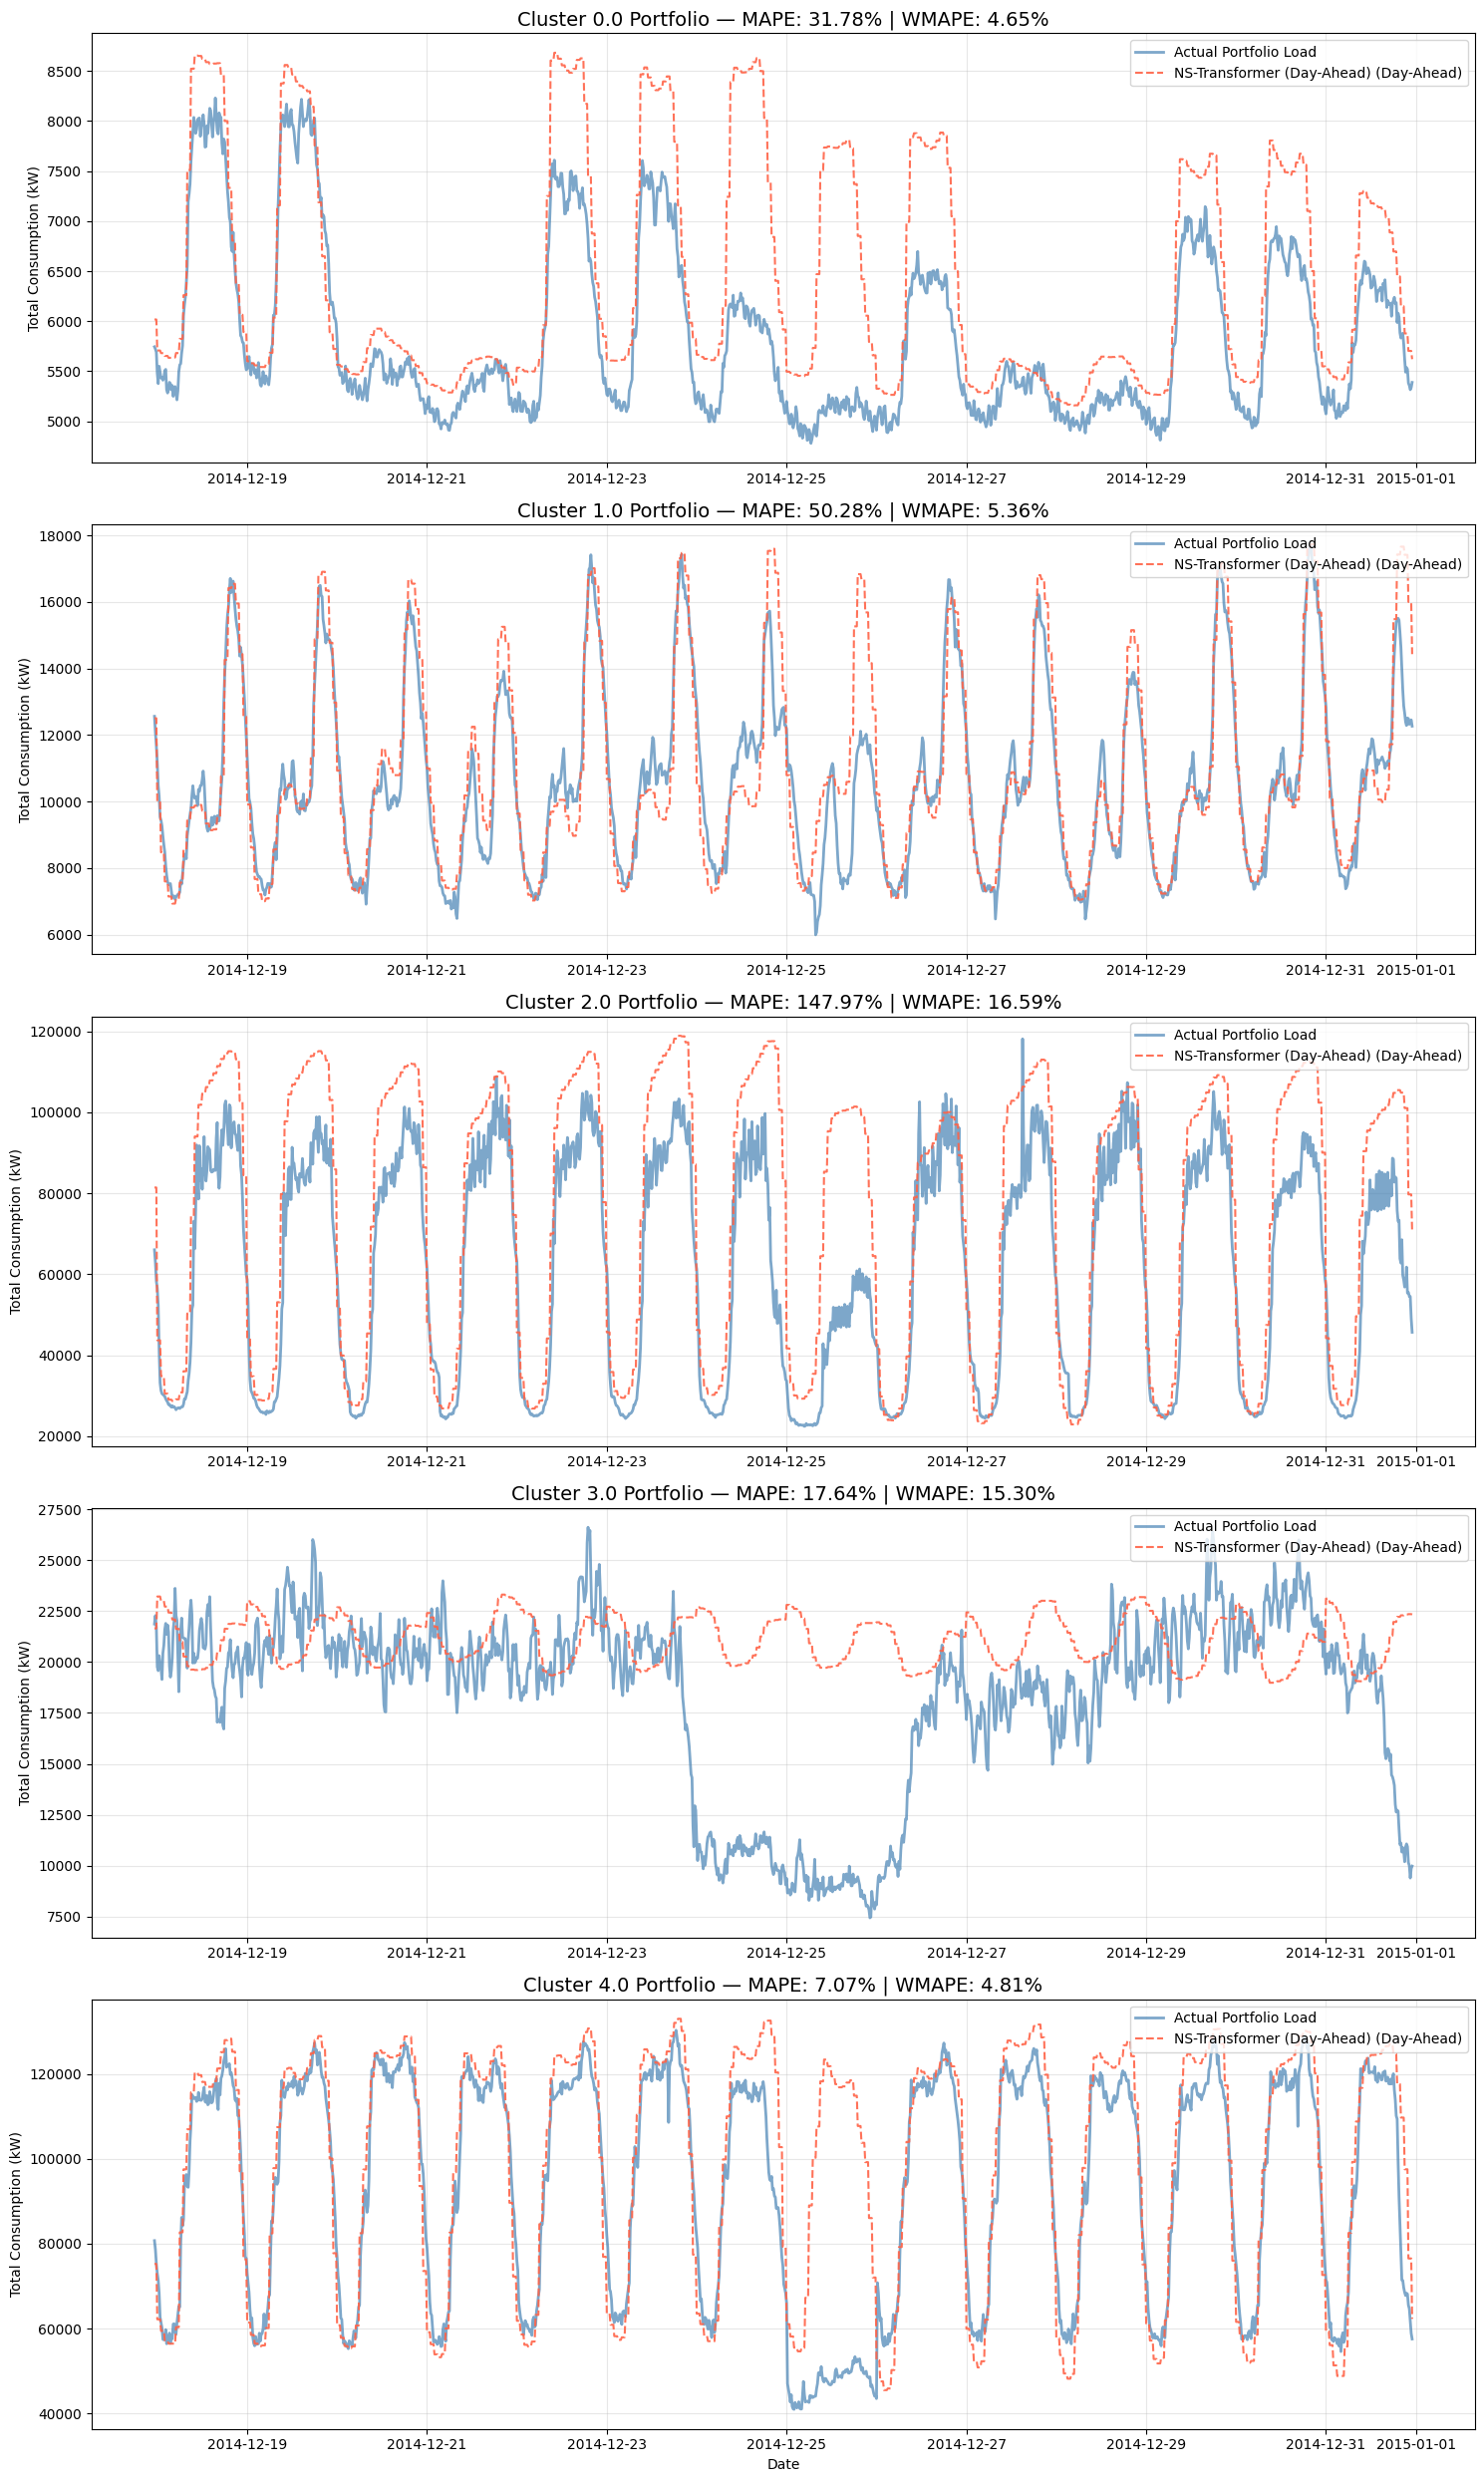

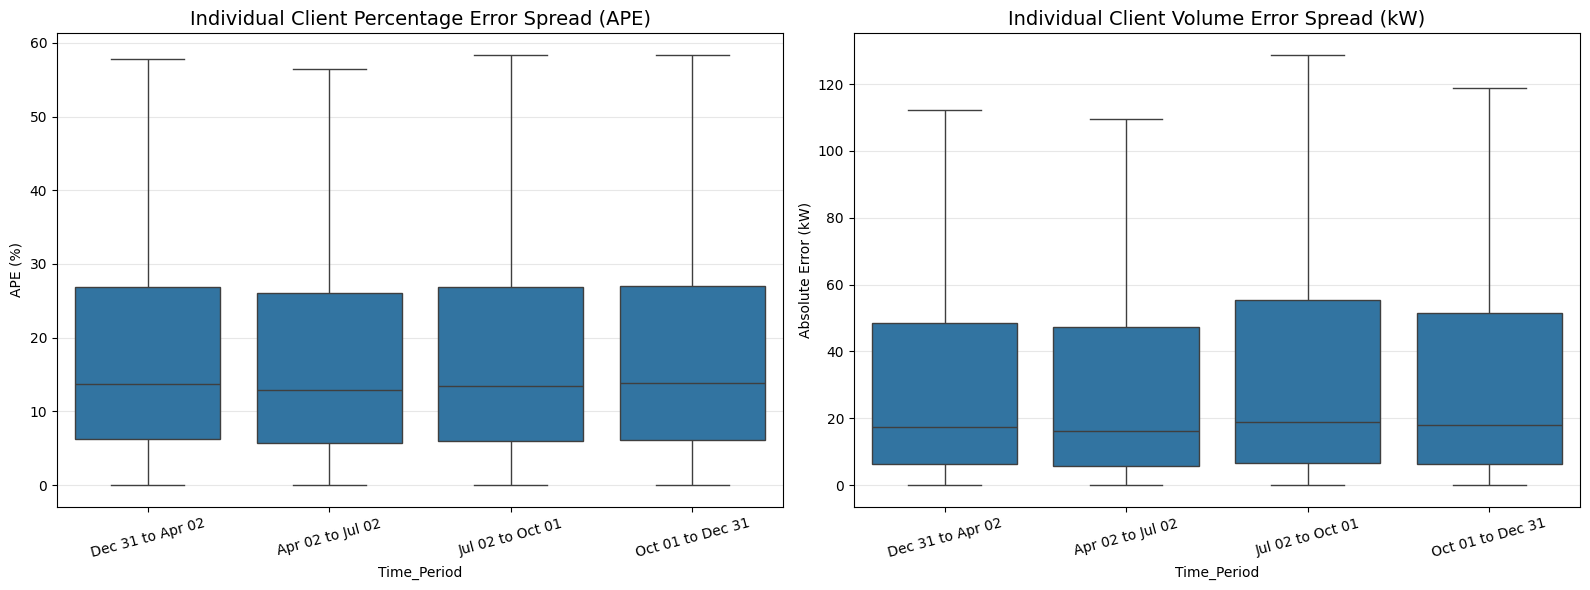

,MAPE,WMAPE
Time_Period,,
Dec 31 to Apr 02,42.58,18.02
Apr 02 to Jul 02,34.03,15.40
Jul 02 to Oct 01,31.82,17.62
Oct 01 to Dec 31,29.86,17.60


In [15]:
# 6. Save models and plot results
print("Saving artifacts to disk...")
save_transformer_artifacts(
    cluster_models, 
    client_scalers, 
    scaler_weather, 
    regressors, 
    mode=MODE
)

print("Generating plots...")
plot_cluster_portfolio(portfolio_eval, summary_da, model_label="NS-Transformer (Day-Ahead)")
analyze_time_periods(test_raw)

## 2. Run Long-Term Scenario
 
We now run the `long_term` scenario. The script will:
- Clean the RAM from the previous execution.
- Segment and scale consumption using ONLY weather and calendar features (no lags).
- Train 5 new neural models.
- Compute WMAPE/MAPE metrics for the strategic hedging portfolio.

In [16]:
# RAM CLEANUP BEFORE LONG-TERM RUN
print("Cleaning memory from Day-Ahead run...")
# Eliminiamo le variabili pesanti della run precedente
del train_agg, test_agg, test_raw, cluster_models, portfolio_eval
gc.collect() # Forza Python a liberare la RAM

# Svuotiamo la cache della GPU del Mac M5
if torch.backends.mps.is_available():
    torch.mps.empty_cache()

# SETUP LONG-TERM
MODE = 'long_term'
print(f"\nStarting pipeline for mode: {MODE.upper()}")
# NOTA: NON ricarichiamo df_long perché è già in memoria!
print(f"Using existing df_long in RAM. Shape: {df_long.shape}")

Cleaning memory from Day-Ahead run...

Starting pipeline for mode: LONG_TERM
Using existing df_long in RAM. Shape: (41548234, 21)


In [17]:
# 2. Preprocess, scale, and split the data
print(f"Running preprocessing for mode: {MODE}...")
train_agg, test_agg, test_raw, client_scalers, scaler_weather, regressors = preprocess_and_split(
    df_long, 
    mode=MODE
)

print("\n--- Preprocessing Checks ---")
print(f"Train Aggregated Shape: {train_agg.shape}")
print(f"Test Aggregated Shape: {test_agg.shape}")
print(f"Regressors (Features) Count: {len(regressors)}")
print(f"Regressors List: {regressors}")

Running preprocessing for mode: long_term...
Preparing train/test split and scaling (Mode: LONG_TERM)...


Scaling Clients: 100%|██████████| 369/369 [00:06<00:00, 54.43it/s]


Aggregating data by Cluster for Transformer training...

--- Preprocessing Checks ---
Train Aggregated Shape: (487675, 11)
Test Aggregated Shape: (175205, 11)
Regressors (Features) Count: 9
Regressors List: ['Consumption', 'HDH', 'CDH', 'HDH_lag24h', 'CDH_lag24h', 'HDH_anomaly', 'CDH_anomaly', 'Is_Weekend', 'Is_Holiday']


In [18]:
# 3. Train the Transformer models per cluster
print("Starting training process...")
cluster_models = train_models(train_agg, regressors)

print(f"\nTraining complete. Models trained: {list(cluster_models.keys())}")

Starting training process...

Training Cluster 0.0
  Epoch 1 | Train: 0.15575 | Val: 0.38468
  Epoch 2 | Train: 0.03911 | Val: 0.41153
  Epoch 3 | Train: 0.03146 | Val: 0.38885
  Epoch 4 | Train: 0.02742 | Val: 0.37501
  Epoch 5 | Train: 0.02427 | Val: 0.37949
  Epoch 6 | Train: 0.02222 | Val: 0.38942
  Epoch 7 | Train: 0.02044 | Val: 0.37381
  Epoch 8 | Train: 0.01885 | Val: 0.37317
  Epoch 9 | Train: 0.01764 | Val: 0.37576
  Epoch 10 | Train: 0.01644 | Val: 0.36287

Training Cluster 1.0
  Epoch 1 | Train: 0.16758 | Val: 0.06201
  Epoch 2 | Train: 0.05688 | Val: 0.04538
  Epoch 3 | Train: 0.04524 | Val: 0.04046
  Epoch 4 | Train: 0.03954 | Val: 0.03520
  Epoch 5 | Train: 0.03599 | Val: 0.03356
  Epoch 6 | Train: 0.03345 | Val: 0.02950
  Epoch 7 | Train: 0.03158 | Val: 0.03079
  Epoch 8 | Train: 0.02988 | Val: 0.02892
  Epoch 9 | Train: 0.02853 | Val: 0.02707
  Epoch 10 | Train: 0.02724 | Val: 0.02683

Training Cluster 2.0
  Epoch 1 | Train: 0.10157 | Val: 0.09175
  Epoch 2 | Train: 0.

In [19]:
# 4. Generate rolling forecasts and un-scale to individual clients
print("Starting prediction and safe merge...")
test_raw = predict_models(
    cluster_models, 
    train_agg, 
    test_agg, 
    test_raw, 
    client_scalers, 
    regressors
)

# CRITICAL CHECK: Verify that the Safe Merge worked and columns exist
print("\n--- Safe Merge Checks ---")
print("Columns in test_raw after prediction:")
print(list(test_raw.columns))

# Let's peek at a few rows that shouldn't be NaN
valid_preds = test_raw.dropna(subset=['Predicted_kW'])
print(f"\nNumber of valid predictions (non-NaN): {len(valid_preds)}")
if len(valid_preds) > 0:
    display(valid_preds[['ClientID', 'Cluster', 'Date', 'Actual_kW', 'Predicted_kW']].head())
else:
    print("WARNING: All predictions are NaN. The merge failed due to date misalignment.")

Starting prediction and safe merge...
Generating forecasts for Cluster 0...
Generating forecasts for Cluster 1...
Generating forecasts for Cluster 2...
Generating forecasts for Cluster 3...
Generating forecasts for Cluster 4...


Un-scaling Clients: 100%|██████████| 369/369 [00:01<00:00, 190.10it/s]



--- Safe Merge Checks ---
Columns in test_raw after prediction:
['Date', 'Weekday', 'Hour', 'Month', 'Is_Weekend', 'Is_Holiday', 'ClientID', 'Consumption', 'HDH', 'CDH', 'Lag_15min', 'Lag_1h', 'Lag_24h', 'Lag_1week', 'HDH_lag24h', 'CDH_lag24h', 'HDH_anomaly', 'CDH_anomaly', 'Rolling_Mean_4h', 'Cluster', 'Consumer_Category', 'Consumption_Scaled', 'Predicted_Consumption_Scaled', 'Predicted_kW', 'Actual_kW']

Number of valid predictions (non-NaN): 12262950


,ClientID,Cluster,Date,Actual_kW,Predicted_kW
0,MT_001,1.0,2014-01-01 00:00:00,2.538071,8.431704
1,MT_001,1.0,2014-01-01 00:15:00,2.538071,8.431704
2,MT_001,1.0,2014-01-01 00:30:00,2.538071,8.431704
3,MT_001,1.0,2014-01-01 00:45:00,2.538071,8.431704
4,MT_001,1.0,2014-01-01 01:00:00,2.538071,6.890187


In [20]:
# 5. Compute portfolio WMAPE and MAPE
print("Evaluating portfolio metrics...")
portfolio_eval, summary_lt = evaluate_models(test_raw)

# Display the summary table
display(summary_lt)

Evaluating portfolio metrics...

Evaluating Portfolio Performance...


,Portfolio_MAPE,Portfolio_WMAPE
Cluster,,
Global,51.64,10.38
0.0,31.97,5.05
1.0,50.13,5.45
2.0,150.78,16.66
3.0,17.83,15.56
4.0,7.47,5.18


Saving artifacts to disk...

Transformer artifacts saved to: /Users/federicogiorgi/Library/CloudStorage/OneDrive-Personal/Documenti/GitHub/forecasting-electricity/agent/artifacts/nst_cluster_long_term.pkl
Generating plots...


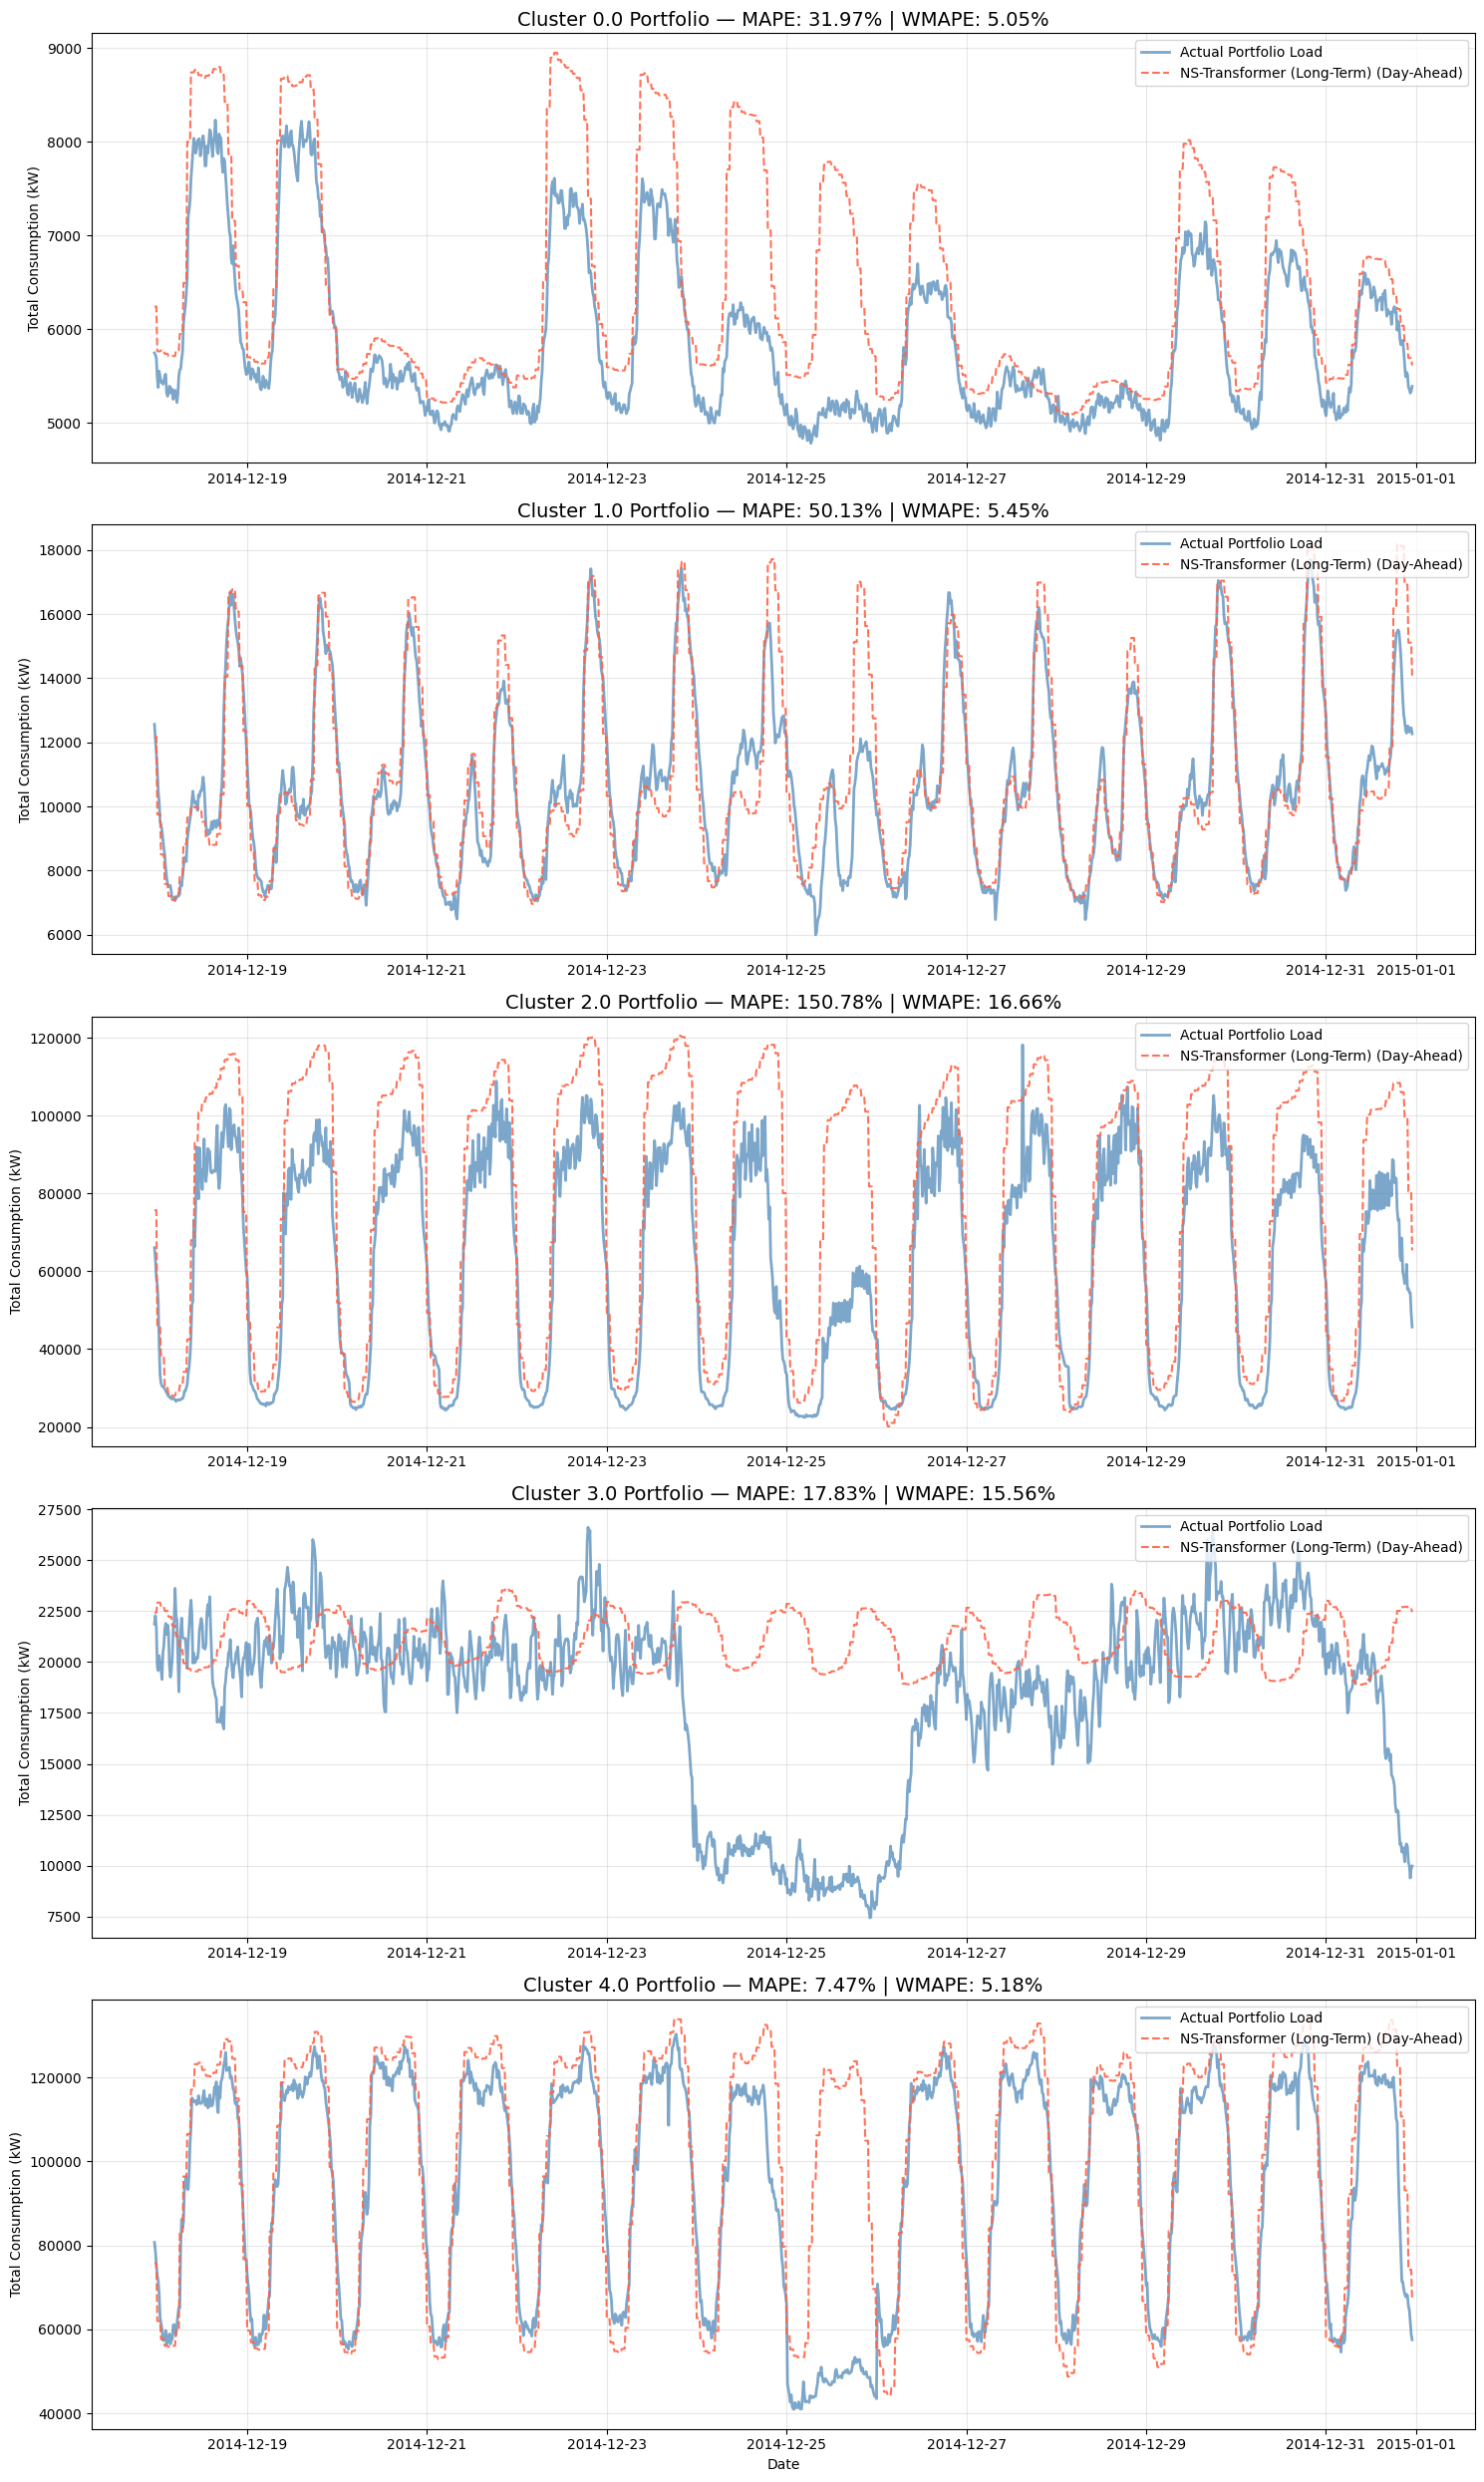

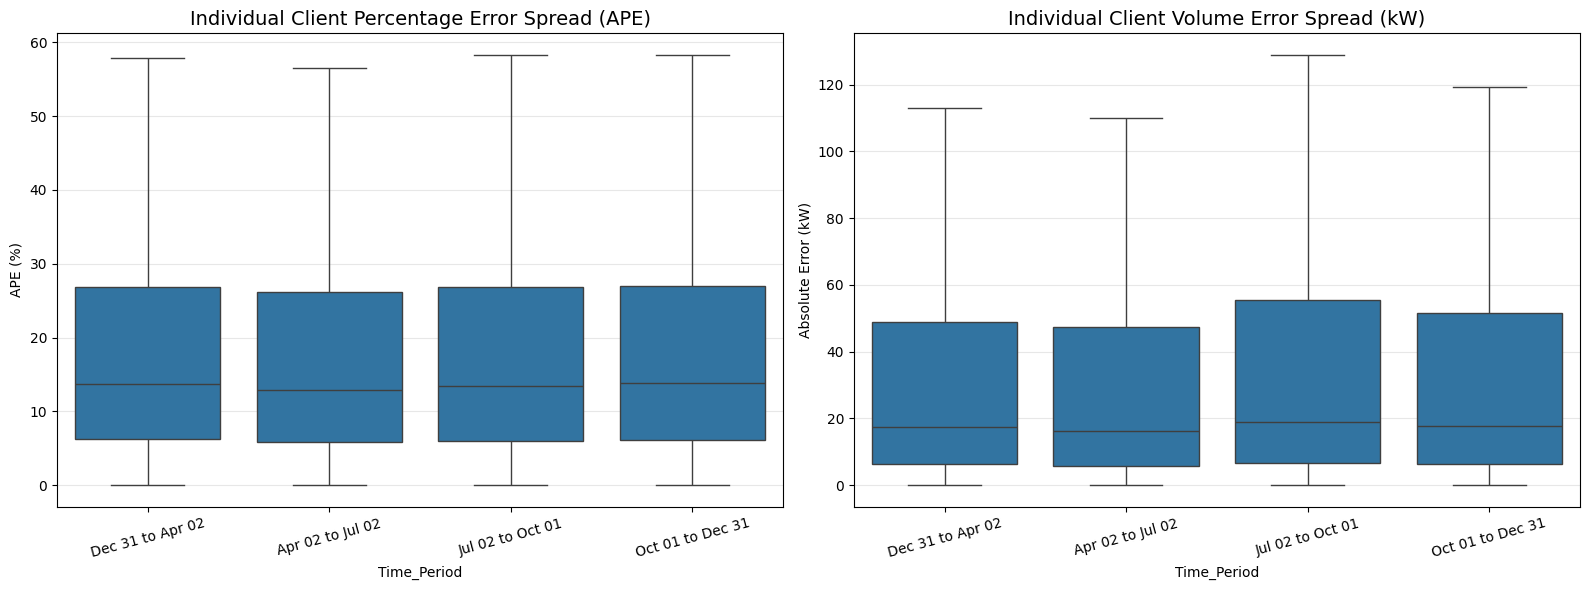

,MAPE,WMAPE
Time_Period,,
Dec 31 to Apr 02,42.67,18.29
Apr 02 to Jul 02,34.42,15.53
Jul 02 to Oct 01,32.11,17.51
Oct 01 to Dec 31,29.96,17.77


In [21]:
# 6. Save models and plot results
print("Saving artifacts to disk...")
save_transformer_artifacts(
    cluster_models, 
    client_scalers, 
    scaler_weather, 
    regressors, 
    mode=MODE
)

print("Generating plots...")
plot_cluster_portfolio(portfolio_eval, summary_lt, model_label="NS-Transformer (Long-Term)")
analyze_time_periods(test_raw)